# A02 — The Bloch Sphere, Built From Scratch

**Track A — under the hood.** Pure NumPy. Qiskit is not imported anywhere in this
notebook. `qviz.bloch` draws the sphere's *frame*; every arrow on it is a vector
this notebook computes for itself.

---

## Where we left off

A01 finished by counting: a qubit is two complex numbers, that's four real
parameters, and two of them are not physical (normalization eats one, global
phase eats another). Two real degrees of freedom survive, and we wrote them as
two angles:

$$|\psi\rangle = \cos\tfrac{\theta}{2}\,|0\rangle + e^{i\phi}\sin\tfrac{\theta}{2}\,|1\rangle,
\qquad \theta \in [0,\pi],\ \phi \in [0,2\pi).$$

Look at those ranges. $\theta$ runs from $0$ to $\pi$; $\phi$ wraps around after
$2\pi$. That is *exactly* the coordinate system a geographer uses: colatitude and
longitude. So the natural home for a qubit state is the surface of a ball, with
$|0\rangle$ at the north pole and $|1\rangle$ at the south.

That object is the **Bloch sphere**, and this notebook builds it from nothing.

## The one thing that is easy to get wrong

The half-angle. A state at $\theta = \pi$ is $|1\rangle$ — but the *state vector*
only rotated by $\theta/2 = \pi/2$ in Hilbert space, where $|0\rangle$ and
$|1\rangle$ are at right angles, not opposite each other.

That factor of two is not a bookkeeping wart. It is the whole reason the picture
works:

> **On the Bloch sphere, orthogonal states are antipodal.**

Perpendicular in Hilbert space becomes *diametrically opposite* on the sphere.
$|0\rangle$/$|1\rangle$, $|+\rangle$/$|-\rangle$, $|{+}i\rangle$/$|{-}i\rangle$
— three orthonormal bases, three axes, six poles. Figure 5 proves it numerically.

But we are not going to *assume* the sphere. We are going to derive the map from
a state to a point, and check it is a bijection onto the unit sphere.

In [1]:
from qviz import backends, bloch, grid, style

import matplotlib.pyplot as plt
import numpy as np

style.use()

SEED = backends.seed_for("A02")
rng = np.random.default_rng(SEED)
print("seed:", SEED)

seed: 20260806


## The map: state $\to$ three real numbers

Here is the honest derivation, and it starts by throwing away the state vector.

A state vector carries a global phase that isn't physical. The object that
doesn't is the **density matrix**

$$\rho = |\psi\rangle\langle\psi|,$$

because $e^{i\varphi}|\psi\rangle$ gives $e^{i\varphi}e^{-i\varphi}\rho = \rho$.
The phase cancels against its own conjugate. So $\rho$ is a faithful label for the
*physical* state, which is what we want to draw.

$\rho$ is a $2\times2$ Hermitian matrix with trace 1. Now count again: a
$2\times2$ Hermitian matrix has 4 real parameters (2 real on the diagonal, 1
complex off-diagonal), and the trace condition removes one. **Three.** Same
answer as before... but wait, A01 said *two*.

Both are right, and the tension is the point. Three numbers with one constraint
($\rho^2 = \rho$ for a pure state, which forces the three onto a sphere) is two
degrees of freedom. The three numbers give us room to draw; the constraint is
what makes it a *surface* and not a solid.

To extract them, expand $\rho$ in a basis for Hermitian matrices. The obvious
one is the identity plus the three **Pauli matrices**:

$$X = \begin{pmatrix}0&1\\1&0\end{pmatrix},\quad
Y = \begin{pmatrix}0&-i\\i&0\end{pmatrix},\quad
Z = \begin{pmatrix}1&0\\0&-1\end{pmatrix}.$$

These four are orthogonal under $\langle A,B\rangle = \tfrac12\mathrm{Tr}(A^\dagger B)$,
so *any* qubit density matrix has a unique expansion

$$\rho = \tfrac12\left(I + r_x X + r_y Y + r_z Z\right)
      = \tfrac12\left(I + \vec r\cdot\vec\sigma\right).$$

Taking the trace against each Pauli in turn (using $\mathrm{Tr}(\sigma_j\sigma_k)=2\delta_{jk}$
and $\mathrm{Tr}\,\sigma_j = 0$) picks out the coefficients:

$$\boxed{\ \vec r = \big(\langle X\rangle,\ \langle Y\rangle,\ \langle Z\rangle\big),
\qquad \langle O\rangle = \mathrm{Tr}(\rho\,O) = \langle\psi|O|\psi\rangle.\ }$$

**That is the Bloch vector, and it is nothing more exotic than three
expectation values.** Every coordinate is a number you could measure in a lab:
$r_z$ is how biased the qubit is toward $|0\rangle$ over $|1\rangle$, $r_x$ how
biased toward $|+\rangle$ over $|-\rangle$, $r_y$ toward $|{+}i\rangle$ over
$|{-}i\rangle$. The sphere is a plot of three measurement biases.

Let's write it.

In [2]:
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
PAULIS = (X, Y, Z)


def from_angles(theta, phi):
    """The canonical form A01 ended on: cos(t/2)|0> + e^{i p} sin(t/2)|1>."""
    return np.array([np.cos(theta / 2),
                     np.exp(1j * phi) * np.sin(theta / 2)], dtype=complex)


def density(state):
    """rho = |psi><psi|. The outer product kills the global phase."""
    v = np.asarray(state, dtype=complex).reshape(2, 1)
    return v @ v.conj().T


def expect(op, state):
    """<psi|O|psi>. Real whenever O is Hermitian, so we take .real."""
    return float(np.real(np.vdot(state, op @ state)))


def bloch_vector(state):
    """r = (<X>, <Y>, <Z>) -- the whole map, in one line."""
    return np.array([expect(P, state) for P in PAULIS])


# Sanity: the two ways of writing an expectation value agree.
psi_test = from_angles(1.1, 2.3)
rho_test = density(psi_test)
print("Tr(rho X) =", round(float(np.real(np.trace(rho_test @ X))), 6),
      "   <psi|X|psi> =", round(expect(X, psi_test), 6))
print("Tr(rho)   =", round(float(np.real(np.trace(rho_test))), 6))
print("rho is Hermitian:", np.allclose(rho_test, rho_test.conj().T))
print("rho^2 == rho (pure):", np.allclose(rho_test @ rho_test, rho_test))

Tr(rho X) = -0.59379    <psi|X|psi> = -0.59379
Tr(rho)   = 1.0
rho is Hermitian: True
rho^2 == rho (pure): True


### What the map gives on the six states you already know

Plug the canonical form into $\vec r$ and the trigonometry collapses:

$$\langle Z\rangle = \cos^2\tfrac\theta2 - \sin^2\tfrac\theta2 = \cos\theta,\qquad
\langle X\rangle = \sin\theta\cos\phi,\qquad
\langle Y\rangle = \sin\theta\sin\phi.$$

Those are **spherical polar coordinates**, verbatim. Not "like" them —
identically them. The $(\theta,\phi)$ we were handed by degree-counting in A01
turn out to be latitude and longitude of a genuine unit sphere, with no fudging.

(The $\langle Z\rangle$ line is worth reading twice: $\cos^2\tfrac\theta2$ is
$P(0)$ and $\sin^2\tfrac\theta2$ is $P(1)$, so $r_z = P(0) - P(1)$. The vertical
coordinate on the sphere is literally the measurement bias.)

In [3]:
CARDINALS = [
    ("|0>",  0.0,          0.0),
    ("|1>",  np.pi,        0.0),
    ("|+>",  np.pi / 2,    0.0),
    ("|->",  np.pi / 2,    np.pi),
    ("|+i>", np.pi / 2,    np.pi / 2),
    ("|-i>", np.pi / 2,    3 * np.pi / 2),
]

print(f"{'state':>5} {'theta':>7} {'phi':>7}   {'r = (<X>, <Y>, <Z>)':<26} "
      f"{'|r|':>6} {'P(0)':>6}")
for name, th, ph in CARDINALS:
    s = from_angles(th, ph)
    r = bloch_vector(s)
    analytic = np.array([np.sin(th) * np.cos(ph),
                         np.sin(th) * np.sin(ph),
                         np.cos(th)])
    assert np.allclose(r, analytic, atol=1e-12)   # spherical polars, exactly
    txt = "(" + ", ".join(f"{v:+.2f}" for v in np.round(r, 9) + 0.0) + ")"
    print(f"{name:>5} {th/np.pi:6.2f}pi {ph/np.pi:6.2f}pi   {txt:<26} "
          f"{np.linalg.norm(r):6.3f} {abs(s[0])**2:6.3f}")

state   theta     phi   r = (<X>, <Y>, <Z>)           |r|   P(0)
  |0>   0.00pi   0.00pi   (+0.00, +0.00, +1.00)       1.000  1.000
  |1>   1.00pi   0.00pi   (+0.00, +0.00, -1.00)       1.000  0.000
  |+>   0.50pi   0.00pi   (+1.00, +0.00, +0.00)       1.000  0.500
  |->   0.50pi   1.00pi   (-1.00, +0.00, +0.00)       1.000  0.500
 |+i>   0.50pi   0.50pi   (+0.00, +1.00, +0.00)       1.000  0.500
 |-i>   0.50pi   1.50pi   (+0.00, -1.00, +0.00)       1.000  0.500


Six states, six unit vectors, three axes. And every $|r| = 1$ — not by
construction, but because we asked for the expectation values of a pure state and
got a unit vector back. That is the sphere asserting itself.

### And back again

A picture is only trustworthy if nothing is lost. Going the other way is just
reading the polar coordinates off:

$$\theta = \arccos r_z, \qquad \phi = \mathrm{atan2}(r_y, r_x),$$

or, staying with density matrices, $\rho = \tfrac12(I + \vec r\cdot\vec\sigma)$
directly.

In [4]:
def state_from_bloch(r):
    """Point on the unit sphere -> state vector (in the canonical gauge)."""
    x, y, z = np.asarray(r, dtype=float)
    theta = np.arccos(np.clip(z, -1.0, 1.0))
    phi = np.arctan2(y, x) % (2 * np.pi)
    return from_angles(theta, phi)


def rho_from_bloch(r):
    """rho = (I + r . sigma) / 2 -- the expansion, run backwards."""
    x, y, z = np.asarray(r, dtype=float)
    return 0.5 * (I2 + x * X + y * Y + z * Z)


def haar_qubit(rng):
    """Uniformly random pure state: a normalized complex Gaussian vector."""
    v = rng.normal(size=2) + 1j * rng.normal(size=2)
    return v / np.linalg.norm(v)


print("round trip on 5 random states   (fidelity 1.0 == same physical state)")
print(f"{'|r|':>8} {'fidelity(state -> r -> state)':>32} {'rho matches':>13}")
for _ in range(5):
    s = haar_qubit(rng)
    r = bloch_vector(s)
    back = state_from_bloch(r)
    fid = abs(np.vdot(back, s)) ** 2
    print(f"{np.linalg.norm(r):8.6f} {fid:32.10f} "
          f"{str(np.allclose(rho_from_bloch(r), density(s))):>13}")

round trip on 5 random states   (fidelity 1.0 == same physical state)
     |r|    fidelity(state -> r -> state)   rho matches
1.000000                     1.0000000000          True
1.000000                     1.0000000000          True
1.000000                     1.0000000000          True
1.000000                     1.0000000000          True
1.000000                     1.0000000000          True


Nothing is lost. `state -> r -> state` returns the same *physical* state every
time, and the reconstructed $\rho$ matches on the nose.

Note again that the round-trip test is a **fidelity**, not `np.allclose` on the
vectors. `state_from_bloch` returns the canonical-gauge representative (real,
non-negative $\alpha$), which generally differs from the input by a global phase
— and A01 established that this difference is not a difference. Testing array
equality here is a real bug that a lot of code contains.

So: states $\leftrightarrow$ points on $S^2$, faithfully, in both directions.
Now we can draw.

## Figure 1 — one state, one arrow

Left: the sphere with a single state on it. The arrow is *not* drawn from
$(\theta,\phi)$ — it is drawn from `bloch_vector(psi)`, the three expectation
values computed above, which is the point of doing it this way.

The two arcs show where the angles live: $\theta$ measured down from the north
pole ($|0\rangle$), $\phi$ measured around the equator from the $|+\rangle$ axis.
The dashed lines drop the arrow onto the equatorial plane, which is how you read
$\phi$ off by eye.

Right: the same state as three numbers. Bars are computed expectation values;
the black ticks are the closed-form spherical polars. They land on top of each
other because the derivation above is exact, not approximate.

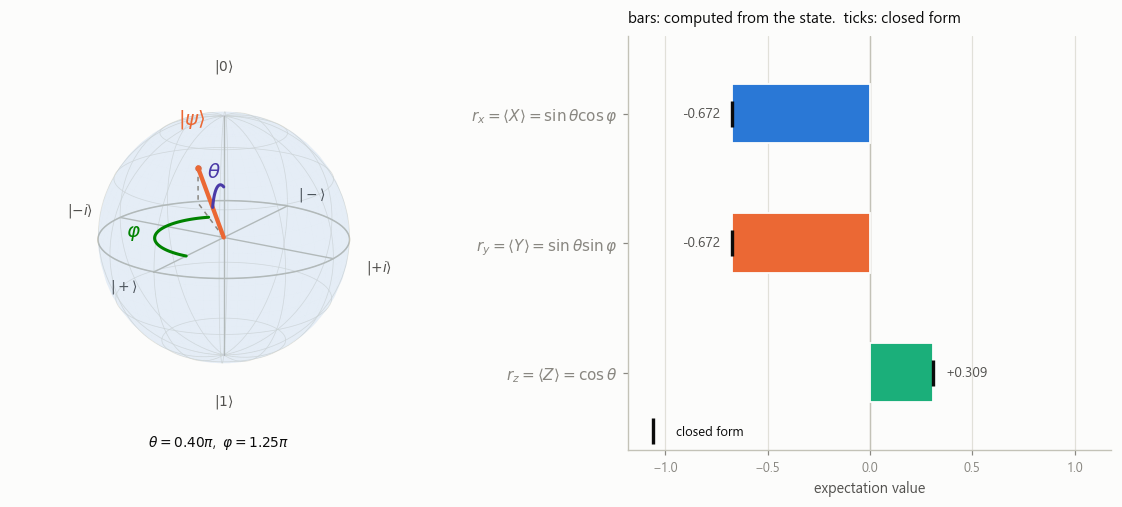

|r| = 1.0
P(0) = (1 + r_z)/2 = 0.654508    |alpha|^2 = 0.654508


In [5]:
TH, PH = 0.40 * np.pi, 1.25 * np.pi      # 72 degrees down, 225 degrees around
psi = from_angles(TH, PH)
r = bloch_vector(psi)


def fill(ax, zoom=1.5):
    """Enlarge a Bloch panel inside its axes.

    mplot3d leaves a lot of slack around the data cube, so a sphere drawn with
    default settings occupies maybe a third of the space allotted to it. The
    ``zoom`` argument of set_box_aspect is the lever that fixes it; without this
    call every 3D panel in this notebook reads as a postage stamp.
    """
    ax.set_box_aspect((1, 1, 1), zoom=zoom)
    return ax


def slerp_arc(a, b, radius=0.45, n=80):
    """Great-circle arc from unit vector a to unit vector b, scaled inward."""
    a = np.asarray(a, float) / np.linalg.norm(a)
    b = np.asarray(b, float) / np.linalg.norm(b)
    ang = np.arccos(np.clip(a @ b, -1.0, 1.0))
    t = np.linspace(0, 1, n)[:, None]
    pts = (np.sin((1 - t) * ang) * a + np.sin(t * ang) * b) / np.sin(ang)
    return pts * radius


fig = plt.figure(figsize=(10.4, 4.5))
ax = fig.add_subplot(1, 2, 1, projection="3d")
bloch.sphere(ax)
fill(ax, 1.55)
bloch.vector(ax, r, color=style.ORANGE, lw=2.8)

# theta arc: from +z round to the state.  phi arc: from +x round the equator.
foot = np.array([r[0], r[1], 0.0])
arc_t = slerp_arc([0, 0, 1], r, 0.42)
arc_p = slerp_arc([1, 0, 0], foot, 0.55)
for arc, col, lab in [(arc_t, style.VIOLET, r"$\theta$"),
                      (arc_p, style.GREEN, r"$\varphi$")]:
    ax.plot(arc[:, 0], arc[:, 1], arc[:, 2], color=col, lw=2.0, zorder=8)
    m = arc[len(arc) // 2] * 1.34
    ax.text(m[0], m[1], m[2], lab, color=col, fontsize=13, ha="center",
            va="center", zorder=9)

for p, q in [(r, foot), ([0, 0, 0], foot)]:
    p, q = np.asarray(p, float), np.asarray(q, float)
    ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]],
            color=style.MUTED, lw=1.0, ls=(0, (3, 3)), zorder=5)

ax.text(r[0] * 1.24, r[1] * 1.24, r[2] * 1.24 + 0.24, r"$|\psi\rangle$",
        color=style.ORANGE, fontsize=13, ha="center", zorder=9)
bloch.label(ax, r"$\theta=0.40\pi$,  $\varphi=1.25\pi$", y=0.04)

# ---- right panel: the same state as three expectation values
axb = fig.add_subplot(1, 2, 2)
analytic = np.array([np.sin(TH) * np.cos(PH), np.sin(TH) * np.sin(PH), np.cos(TH)])
ypos = [2, 1, 0]
axb.barh(ypos, r, height=0.46, color=[style.BLUE, style.ORANGE, style.AQUA],
         edgecolor=style.SURFACE, linewidth=1.2, zorder=3)
axb.plot(analytic, ypos, ls="none", marker="|", ms=17, mew=2.2,
         color=style.INK, zorder=5, label="closed form")
for yv, val in zip(ypos, r):
    axb.text(val + (0.06 if val >= 0 else -0.06), yv, f"{val:+.3f}",
             va="center", ha="left" if val >= 0 else "right",
             fontsize=9, color=style.INK_2, zorder=6)
axb.axvline(0, color=style.AXIS, lw=0.9, zorder=2)
axb.set_yticks(ypos)
axb.set_yticklabels([r"$r_x=\langle X\rangle=\sin\theta\cos\varphi$",
                     r"$r_y=\langle Y\rangle=\sin\theta\sin\varphi$",
                     r"$r_z=\langle Z\rangle=\cos\theta$"], fontsize=10)
axb.set_xlim(-1.18, 1.18)
axb.set_ylim(-0.6, 2.6)
axb.set_xlabel("expectation value")
axb.grid(axis="x", zorder=0)
axb.grid(axis="y", visible=False)
axb.set_axisbelow(True)
axb.legend(loc="lower left")
axb.set_title("bars: computed from the state.  ticks: closed form", fontsize=10)
plt.show()

print("|r| =", round(float(np.linalg.norm(r)), 12))
print("P(0) = (1 + r_z)/2 =", round((1 + r[2]) / 2, 6),
      "   |alpha|^2 =", round(abs(psi[0]) ** 2, 6))

## Figure 2 — the six states you will meet everywhere

$|0\rangle,|1\rangle$ on the $z$ axis. $|+\rangle,|-\rangle$ on $x$.
$|{+}i\rangle,|{-}i\rangle$ on $y$. Three mutually unbiased bases, one per axis,
and the axes are orthogonal in 3D precisely because the bases are unbiased:
measuring $Z$ on an eigenstate of $X$ is a coin flip, and "coin flip" means zero
projection onto that axis.

These six points are the entire vocabulary of single-qubit gates. `X` is a half
turn about the $x$ axis, `H` swaps the $z$ and $x$ poles, `S` rotates the equator
a quarter turn. A03 makes that precise — this figure is the map you will be
navigating.

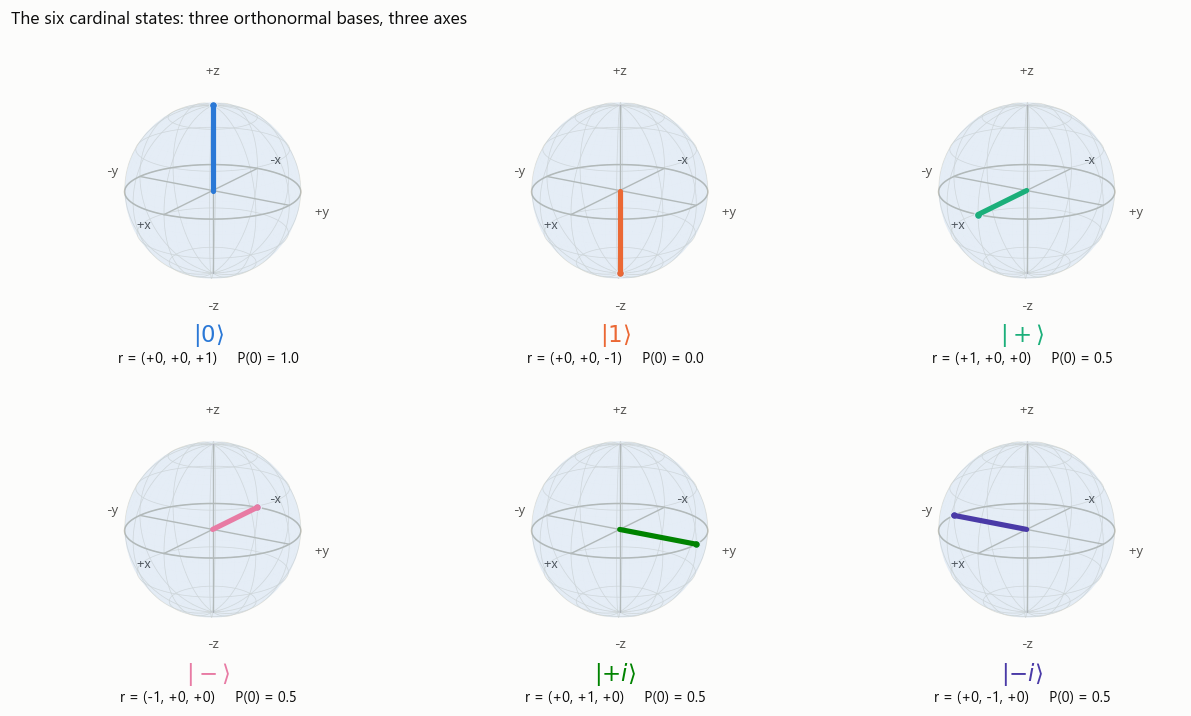

In [6]:
COLORS = [style.BLUE, style.ORANGE, style.AQUA, style.MAGENTA,
          style.GREEN, style.VIOLET]
KETS = ["0", "1", "+", "-", "{+}i", "{-}i"]

fig, axes = grid.frames(6, ncols=3, panel=(3.7, 3.2), projection="3d")
for ax, (name, th, ph), col, k in zip(axes, CARDINALS, COLORS, KETS):
    s = from_angles(th, ph)
    v = bloch_vector(s)                       # computed, not hard-coded
    # Frame labels stay on, but as AXIS names (+x/-x/...) rather than kets: the
    # ket belongs in the caption, and printing it twice per panel -- once on the
    # frame, once underneath -- reads as two different things.
    bloch.sphere(ax, label_kets=False)
    fill(ax, 1.42)
    bloch.vector(ax, v, color=col, lw=3.4)
    bloch.label(ax, grid.ket(k), y=0.10, size=15, color=col)
    # +0.0 turns a "-0.00" into "0.00" -- "(-0, -1, +0)" reads as a bug.
    txt = "r = (" + ", ".join(f"{c:+.0f}" for c in np.round(v, 9) + 0.0) + ")"
    bloch.label(ax, txt + f"     P(0) = {abs(s[0])**2:.1f}", y=0.01, size=9.5)
fig.suptitle("The six cardinal states: three orthonormal bases, three axes",
             x=0.005, ha="left", fontsize=11.5)
plt.show()

Notice the pattern in the printed $P(0)$: it is $1$ at the north pole, $0$ at
the south, and exactly $\tfrac12$ everywhere on the equator. Height *is*
probability. The four equatorial states are indistinguishable to a $Z$
measurement and differ only in $\phi$ — which is A01's "relative phase", now
visible as an angle you can point at.

## Figure 3 — flattening the sphere: the stereographic map

Why a *sphere* and not, say, a square patch of the $(\theta,\phi)$ plane? Because
the sphere is what you get when you take seriously that the state is
$\alpha|0\rangle + \beta|1\rangle$ **up to scale**. Only the ratio matters:

$$w = \frac{\beta}{\alpha} = \tan\tfrac\theta2\,e^{i\phi} \in \mathbb{C}\cup\{\infty\}.$$

One complex number, plus a point at infinity for $\alpha = 0$. And the complex
plane plus a point at infinity **is** a sphere — the Riemann sphere — glued
together by stereographic projection. Qubit states are the complex projective
line $\mathbb{CP}^1$, and $\mathbb{CP}^1 \cong S^2$. That isomorphism is the
Bloch sphere. It is a theorem, not a mnemonic.

The projection: stand at the south pole $|1\rangle$, look at a point on the
sphere, and follow your line of sight until it crosses the equatorial plane.
Middle panel shows the geometry in cross-section; the arithmetic is
$w = (r_x + i r_y)/(1 + r_z)$, whose modulus is $\tan\tfrac\theta2$.

Both maps are coloured by $P(0) = 1/(1+|w|^2)$. Follow a colour across the three
panels: the same physics, once wrapped on a ball and once laid flat.

beta/alpha            = (-0.794977-0.03287j)
stereographic(r)      = [-0.794977 -0.03287 ]


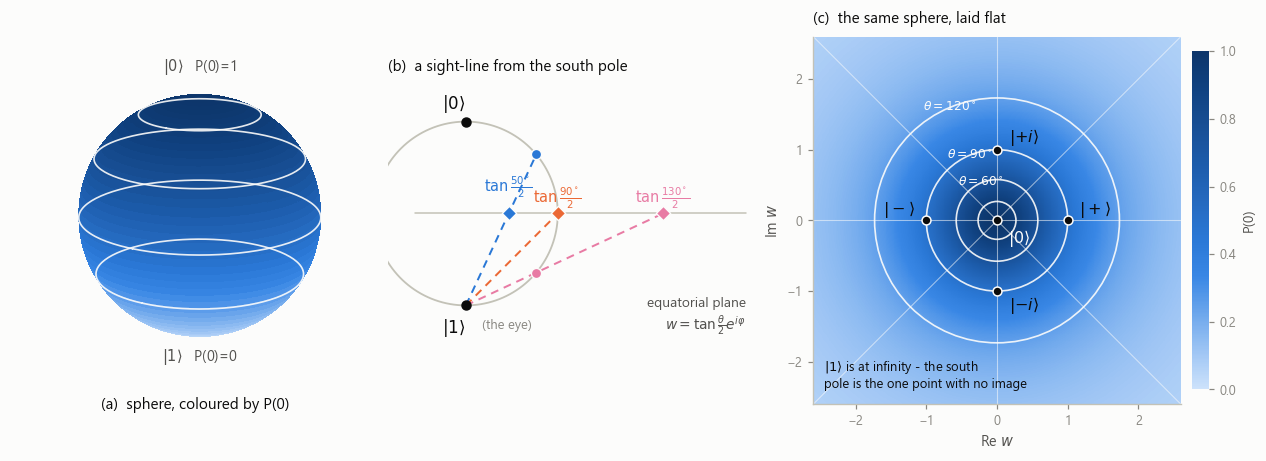

In [7]:
def stereographic(r):
    """Project (x, y, z) from the south pole onto the equatorial plane."""
    x, y, z = np.asarray(r, dtype=float)
    return np.array([x / (1 + z), y / (1 + z)])


# The ratio beta/alpha IS the projection -- check on a random state.
_s = haar_qubit(rng)
_w = _s[1] / _s[0]
print("beta/alpha            =", np.round(_w, 6))
print("stereographic(r)      =", np.round(stereographic(bloch_vector(_s)), 6))

RINGS = [30, 60, 90, 120]          # lines of constant theta, in degrees
LIM = 2.6

fig = plt.figure(figsize=(11.4, 4.15))

# ---- (a) the sphere, painted by P(0)
axa = fig.add_subplot(1, 3, 1, projection="3d")
bloch.sphere(axa, alpha=0.0, wire=False, equator=False, tick_axes=False,
             labels=False)
fill(axa, 1.68)
u = np.linspace(0, 2 * np.pi, 72)
v = np.linspace(0, np.pi, 48)
sx = np.outer(np.cos(u), np.sin(v))
sy = np.outer(np.sin(u), np.sin(v))
sz = np.outer(np.ones_like(u), np.cos(v))
# alpha stays at 1.0: anything less and adjacent quads blend at their shared
# edge, which paints a crosshatch of seams that reads as structure.
axa.plot_surface(sx, sy, sz, facecolors=style.SEQ((1 + sz) / 2), rstride=1,
                 cstride=1, linewidth=0, shade=False, antialiased=False,
                 zorder=1)
for deg in RINGS:                                    # white lines of latitude
    a = np.deg2rad(deg)
    t = np.linspace(0, 2 * np.pi, 160)
    axa.plot(np.sin(a) * np.cos(t), np.sin(a) * np.sin(t),
             np.cos(a) * np.ones_like(t), color=style.SURFACE, lw=1.1,
             alpha=0.9, zorder=6)
axa.text(0, 0, 1.26, grid.ket("0") + "   P(0)=1", color=style.INK_2,
         fontsize=9.5, ha="center", va="center")
axa.text(0, 0, -1.26, grid.ket("1") + "   P(0)=0", color=style.INK_2,
         fontsize=9.5, ha="center", va="center")
bloch.label(axa, "(a)  sphere, coloured by P(0)", y=0.02, size=10)

# ---- (b) the projection itself, in cross-section
axb = fig.add_subplot(1, 3, 2)
t = np.linspace(0, 2 * np.pi, 300)
axb.plot(np.cos(t), np.sin(t), color=style.AXIS, lw=1.2, zorder=2)
axb.plot([-0.55, 3.05], [0, 0], color=style.AXIS, lw=1.0, zorder=1)
axb.scatter([0, 0], [1, -1], s=34, color=style.INK, zorder=6)
axb.text(-0.13, 1.14, grid.ket("0"), fontsize=11, ha="center", color=style.INK)
axb.text(-0.13, -1.30, grid.ket("1"), fontsize=11, ha="center", color=style.INK)
axb.text(0.10, -1.26, "  (the eye)", fontsize=8.5, ha="left", color=style.MUTED)
for deg, col, dy in zip([50, 90, 130],
                        [style.BLUE, style.ORANGE, style.MAGENTA],
                        [0.24, 0.12, 0.12]):   # stagger: 50 and 90 land close
    a = np.deg2rad(deg)
    px, pz = np.sin(a), np.cos(a)          # the point on the sphere
    wx = np.tan(a / 2)                     # where the sight-line crosses z=0
    # The line of sight starts at the south pole and runs THROUGH both; which
    # of the two comes first depends on the hemisphere, so draw out to the
    # farther one and let the nearer sit on the segment.
    far = (px, pz) if px ** 2 + (pz + 1) ** 2 > wx ** 2 + 1 else (wx, 0.0)
    axb.plot([0, far[0]], [-1, far[1]], color=col, lw=1.3, ls=(0, (4, 3)),
             zorder=3)
    axb.scatter([px], [pz], s=44, color=col, zorder=7, edgecolors=style.SURFACE,
                linewidths=0.9)
    axb.scatter([wx], [0], s=44, marker="D", color=col, zorder=7,
                edgecolors=style.SURFACE, linewidths=0.9)
    axb.text(wx, dy, rf"$\tan\frac{{{deg}^\circ}}{{2}}$", color=col,
             fontsize=9.5, ha="center")
axb.text(3.05, -1.34, "equatorial plane" + "\n" + r"$w=\tan\frac{\theta}{2}e^{i\varphi}$",
         fontsize=9, ha="right", va="bottom", color=style.INK_2)
axb.set_xlim(-0.85, 3.15)
axb.set_ylim(-1.55, 1.40)
axb.set_aspect("equal")
axb.set_axis_off()
axb.set_title("(b)  a sight-line from the south pole", fontsize=10)

# ---- (c) the flat map
axc = fig.add_subplot(1, 3, 3)
g = np.linspace(-LIM, LIM, 420)
WX, WY = np.meshgrid(g, g)
P0 = 1.0 / (1.0 + WX ** 2 + WY ** 2)
im = axc.pcolormesh(WX, WY, P0, cmap=style.SEQ, vmin=0, vmax=1, shading="auto",
                    rasterized=True, zorder=1)
for deg in RINGS:
    rad = np.tan(np.deg2rad(deg) / 2)
    axc.add_patch(plt.Circle((0, 0), rad, fill=False, color=style.SURFACE,
                             lw=1.1, alpha=0.9, zorder=3))
    # Labels ride the 112.5 deg diagonal, between two meridians, so they never
    # sit on a line; the inner rings are close together so only tag the outer.
    if deg >= 60:
        a = np.deg2rad(112.5)
        axc.text(rad * np.cos(a), rad * np.sin(a), rf"$\theta={deg}^\circ$",
                 fontsize=8, color=style.SURFACE, ha="center", va="center",
                 zorder=5)
for k in range(8):                                   # meridians = constant phi
    a = k * np.pi / 4
    axc.plot([0, LIM * 1.5 * np.cos(a)], [0, LIM * 1.5 * np.sin(a)],
             color=style.SURFACE, lw=0.7, alpha=0.55, zorder=2)
# |0> sits on the darkest part of the map, so its label flips to the surface
# colour -- ink on that blue is unreadable.
marks = [(0, 0, "0", (0.15, -0.26), "left", style.SURFACE),
         (1, 0, "+", (0.16, 0.16), "left", style.INK),
         (-1, 0, "-", (-0.16, 0.16), "right", style.INK),
         (0, 1, "{+}i", (0.17, 0.17), "left", style.INK),
         (0, -1, "{-}i", (0.17, -0.20), "left", style.INK)]
for mx, my, k, (dx, dy), ha, tc in marks:
    axc.scatter([mx], [my], s=34, color=style.INK, zorder=6,
                edgecolors=style.SURFACE, linewidths=1.0)
    axc.text(mx + dx, my + dy, grid.ket(k), fontsize=10.5, color=tc,
             ha=ha, va="center", zorder=6)
axc.text(-LIM * 0.94, -LIM * 0.93,
         grid.ket("1") + " is at infinity - the south" + "\n"
         + "pole is the one point with no image",
         fontsize=8.5, color=style.INK, ha="left", va="bottom", zorder=7)
axc.set_xlim(-LIM, LIM)
axc.set_ylim(-LIM, LIM)
axc.set_aspect("equal")
axc.set_xlabel("Re $w$")
axc.set_ylabel("Im $w$")
axc.grid(False)
axc.set_title("(c)  the same sphere, laid flat", fontsize=10)
cb = fig.colorbar(im, ax=axc, fraction=0.046, pad=0.03)
cb.set_label("P(0)", fontsize=9)
cb.outline.set_visible(False)
plt.show()

The flat map is honest about *one* thing and dishonest about another, in exactly
the way every world map is. Angles are preserved — stereographic projection is
conformal, so the meridians still meet the latitude rings at right angles. Area
is destroyed: the equator (the $90^\circ$ ring) is a modest circle of radius 1,
while everything south of it sprawls outward forever and $|1\rangle$ never
arrives.

Hold onto that distortion. It is the *same* distortion that makes naive sampling
go wrong in the next figure.

## Figure 4 — the key figure: how to sample a sphere, and how not to

Here is a question with a trap in it. *"Give me 2000 random qubit states."*

The obvious move: $\theta$ is in $[0,\pi]$, so draw it uniformly; $\phi$ is in
$[0,2\pi)$, draw that uniformly too. Two uniform draws, one random state. It is
the first thing almost everyone writes, and it is wrong — visibly, dramatically
wrong.

The reason is that $(\theta,\phi)$ are coordinates, and coordinates are not area.
The patch of sphere covered by a small $d\theta\,d\phi$ rectangle has area

$$dA = \sin\theta\;d\theta\;d\phi,$$

because a ring of constant $\theta$ has circumference $2\pi\sin\theta$, which
shrinks to nothing at the poles. Uniform $\theta$ therefore puts the *same number
of points* on the tiny ring near the pole as on the enormous ring at the equator.
The poles get crowded.

The fix is to sample the thing that *is* uniform. Since $d(\cos\theta) =
-\sin\theta\,d\theta$, the measure $\sin\theta\,d\theta\,d\phi$ is just
$d(\cos\theta)\,d\phi$ — so **draw $z = \cos\theta$ uniformly on $[-1,1]$**.
(This is Archimedes' hat-box theorem: equal slabs of a sphere have equal area.
It has been known for 2200 years and is still the most-forgotten fact in
graphics code.)

The Haar measure — the unique distribution on states that no unitary can
change — does this for free: normalize a complex Gaussian vector and the Bloch
points come out uniform on $S^2$. That is the recipe A01 already used, and now
we can see why it matters.

In [8]:
N = 2000

# (1) Haar: normalized complex Gaussians -> uniform on the sphere.
g = rng.normal(size=(N, 2)) + 1j * rng.normal(size=(N, 2))
haar_states = g / np.linalg.norm(g, axis=1, keepdims=True)
haar_r = np.stack([
    np.einsum("ni,ij,nj->n", haar_states.conj(), P, haar_states).real
    for P in PAULIS], axis=1)

# (2) Naive: theta ~ U(0, pi), phi ~ U(0, 2pi).
th_n = rng.uniform(0, np.pi, N)
ph_n = rng.uniform(0, 2 * np.pi, N)
naive_states = np.stack([np.cos(th_n / 2),
                         np.exp(1j * ph_n) * np.sin(th_n / 2)], axis=1)
naive_r = np.stack([
    np.einsum("ni,ij,nj->n", naive_states.conj(), P, naive_states).real
    for P in PAULIS], axis=1)

CAP = np.cos(np.deg2rad(30))       # polar caps: |z| > cos(30 deg)
# Archimedes: a cap of angular radius a is (1 - cos a)/2 of the sphere's area,
# so the two of them together are exactly 1 - cos(30 deg).
area_frac = 1 - CAP
print(f"the two polar caps within 30 deg of a pole are "
      f"{100*area_frac:.1f}% of the sphere's area")
for nm, arr in [("Haar ", haar_r), ("naive", naive_r)]:
    frac = np.mean(np.abs(arr[:, 2]) > CAP)
    print(f"  {nm}: {100*frac:5.1f}% of samples land there  "
          f"(x{frac/area_frac:.2f} the fair share)")

the two polar caps within 30 deg of a pole are 13.4% of the sphere's area
  Haar :  12.6% of samples land there  (x0.94 the fair share)
  naive:  32.9% of samples land there  (x2.46 the fair share)


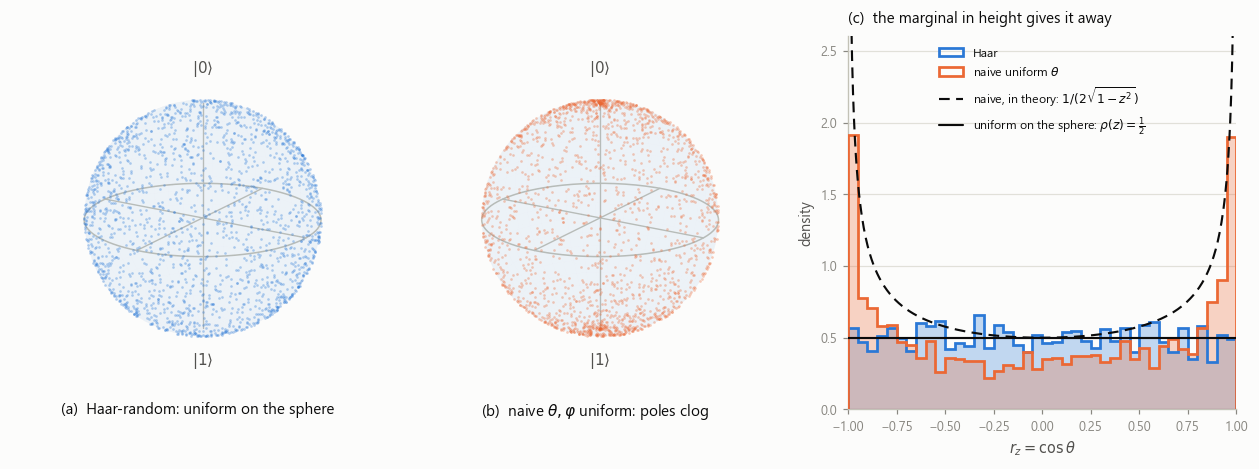

In [9]:
fig = plt.figure(figsize=(11.4, 4.15))

for j, (arr, col, ttl) in enumerate([
        (haar_r, style.BLUE, "(a)  Haar-random: uniform on the sphere"),
        (naive_r, style.ORANGE, r"(b)  naive $\theta,\varphi$ uniform: poles clog")]):
    ax = fig.add_subplot(1, 3, j + 1, projection="3d")
    bloch.sphere(ax, alpha=0.035, wire=False, labels=False)
    fill(ax, 1.62)
    ax.scatter(arr[:, 0], arr[:, 1], arr[:, 2], s=3.0, color=col, alpha=0.34,
               depthshade=False, linewidths=0, rasterized=True, zorder=5)
    ax.text(0, 0, 1.30, grid.ket("0"), color=style.INK_2, fontsize=10,
            ha="center", va="center")
    ax.text(0, 0, -1.30, grid.ket("1"), color=style.INK_2, fontsize=10,
            ha="center", va="center")
    bloch.label(ax, ttl, y=0.02, size=10)

ax3 = fig.add_subplot(1, 3, 3)
bins = np.linspace(-1, 1, 41)
for arr, col, lab in [(haar_r, style.BLUE, "Haar"),
                      (naive_r, style.ORANGE, r"naive uniform $\theta$")]:
    ax3.hist(arr[:, 2], bins=bins, density=True, histtype="stepfilled",
             color=col, alpha=0.28, zorder=3)
    ax3.hist(arr[:, 2], bins=bins, density=True, histtype="step",
             color=col, lw=1.8, label=lab, zorder=4)
zz = np.linspace(-0.999, 0.999, 400)
ax3.plot(zz, 1 / (2 * np.sqrt(1 - zz ** 2)), color=style.INK, lw=1.4,
         ls=(0, (5, 3)), zorder=5,
         label=r"naive, in theory: $1/(2\sqrt{1-z^2})$")
ax3.axhline(0.5, color=style.INK, lw=1.4, zorder=5,
            label=r"uniform on the sphere: $\rho(z)=\frac{1}{2}$")
ax3.set_xlabel(r"$r_z = \cos\theta$")
ax3.set_ylabel("density")
ax3.set_ylim(0, 2.6)
ax3.set_xlim(-1, 1)
ax3.legend(loc="upper center", fontsize=8)
ax3.set_title("(c)  the marginal in height gives it away", fontsize=10)
plt.show()

Panel (c) is the whole argument in one line. For a genuinely uniform sphere the
density of $z=\cos\theta$ is **flat** at $\tfrac12$ — Archimedes again. Uniform
$\theta$ instead produces $\rho(z) = 1/(2\sqrt{1-z^2})$, which diverges at
$z=\pm1$: the dashed curve, which the orange histogram tracks precisely.

The 3D panels make the same point with your eyes: (a) is an even fog, (b) has two
obvious bald patches around the equator and two dark caps. And the printed
numbers put a figure on it — the naive sampler over-populates the polar caps by
roughly a factor of two.

**Why you should care beyond aesthetics.** Randomized benchmarking, shadow
tomography, barren-plateau studies, and every "average over random states"
benchmark are all statements about the Haar measure. Sample it wrong and your
average is an average over a different distribution — one biased toward
computational basis states, which are exactly the easiest states for most
algorithms. The bug flatters your results and never raises an exception.

## Figure 5 — antipodal means orthogonal

Time to cash the promise from the top of the notebook.

Take two states with Bloch vectors $\vec r_1, \vec r_2$ separated by angle
$\gamma$. Their overlap is

$$|\langle\psi_1|\psi_2\rangle|^2 = \mathrm{Tr}(\rho_1\rho_2)
= \mathrm{Tr}\!\left[\tfrac14(I+\vec r_1\!\cdot\vec\sigma)(I+\vec r_2\!\cdot\vec\sigma)\right]
= \frac{1 + \vec r_1\cdot\vec r_2}{2} = \frac{1+\cos\gamma}{2} = \cos^2\frac{\gamma}{2}.$$

(The middle step uses $\mathrm{Tr}(\sigma_j\sigma_k) = 2\delta_{jk}$ once more —
the cross terms in $\vec r_1\cdot\vec\sigma$ times $\vec r_2\cdot\vec\sigma$
collapse to a dot product.)

Read off the consequences:

- $\gamma = 0$: fidelity 1. Same point, same state.
- $\gamma = 90°$: fidelity $\tfrac12$. Perpendicular axes are *unbiased* bases —
  $|0\rangle$ tells you nothing about an $X$ measurement.
- $\gamma = 180°$: fidelity **0**. Antipodal points are orthogonal states.

And there is the missing factor of two, returned with interest: the half-angle in
$\cos\tfrac\theta2$ is the same half-angle in $\cos^2\tfrac\gamma2$. The Bloch
sphere runs at double the angle of Hilbert space, which is why a $90°$ Hilbert-space
rotation shows up as a $180°$ flip on the ball.

                         r              -r (antipode)   fidelity
(+0.481, +0.204, +0.853)  (-0.481, -0.204, -0.853)   1.00e-32
(-0.811, +0.488, -0.323)  (+0.811, -0.488, +0.323)   6.55e-32
(+0.170, -0.897, +0.408)  (-0.170, +0.897, -0.408)   4.81e-33


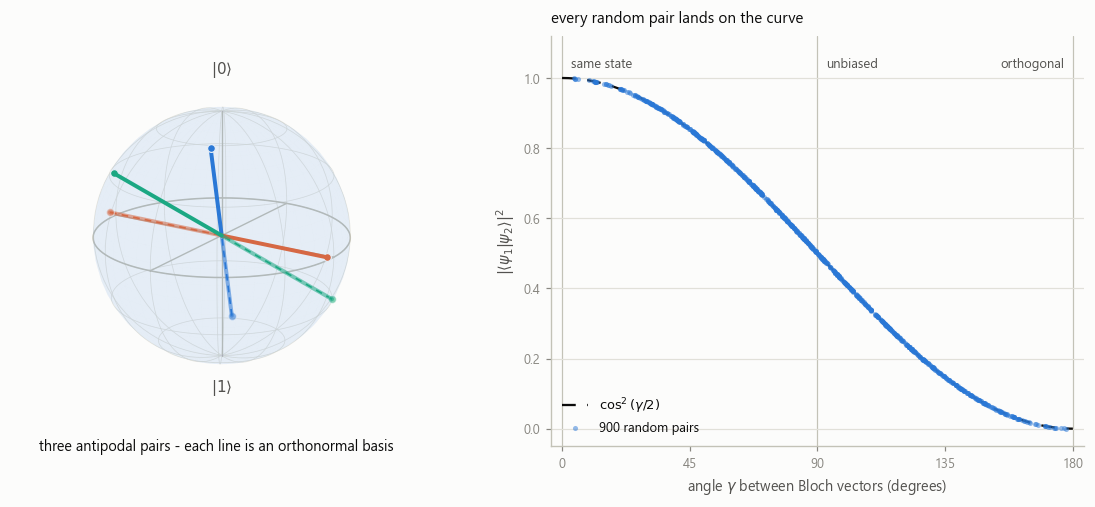


max deviation from cos^2(gamma/2): 6.66e-16


In [10]:
def fidelity(a, b):
    return float(abs(np.vdot(a, b)) ** 2)


PAIRS = [(0.55, 0.4), (1.9, 2.6), (1.15, 4.9)]
PAIR_COLS = [style.BLUE, style.ORANGE, style.AQUA]

fig = plt.figure(figsize=(10.4, 4.5))

ax = fig.add_subplot(1, 2, 1, projection="3d")
bloch.sphere(ax, labels=False)
fill(ax, 1.6)
print(f"{'r':>26} {'-r (antipode)':>26} {'fidelity':>10}")
for (th, ph), col in zip(PAIRS, PAIR_COLS):
    s = from_angles(th, ph)
    v = bloch_vector(s)
    anti = state_from_bloch(-v)                 # the point straight through
    ax.plot([-v[0], v[0]], [-v[1], v[1]], [-v[2], v[2]], color=col, lw=1.1,
            ls=(0, (4, 3)), zorder=4)
    bloch.vector(ax, v, color=col, lw=2.6)
    bloch.vector(ax, -v, color=col, lw=2.6, alpha=0.55)
    f = fidelity(s, anti)
    print("(" + ", ".join(f"{c:+.3f}" for c in v) + ")",
          " (" + ", ".join(f"{c:+.3f}" for c in -v) + ")", f"{f:10.2e}")
    assert abs(np.vdot(s, anti)) < 1e-12
ax.text(0, 0, 1.30, grid.ket("0"), color=style.INK_2, fontsize=10, ha="center")
ax.text(0, 0, -1.30, grid.ket("1"), color=style.INK_2, fontsize=10, ha="center")
bloch.label(ax, "three antipodal pairs - each line is an orthonormal basis",
            y=0.02, size=9.5)

# ---- fidelity against Bloch angle, for random pairs
axf = fig.add_subplot(1, 2, 2)
M = 900
a = np.stack([haar_qubit(rng) for _ in range(M)])
b = np.stack([haar_qubit(rng) for _ in range(M)])
ra = np.stack([np.einsum("ni,ij,nj->n", a.conj(), P, a).real for P in PAULIS], 1)
rb = np.stack([np.einsum("ni,ij,nj->n", b.conj(), P, b).real for P in PAULIS], 1)
gamma = np.degrees(np.arccos(np.clip(np.sum(ra * rb, axis=1), -1, 1)))
fid = np.abs(np.sum(a.conj() * b, axis=1)) ** 2

# Curve underneath, points on top: the claim is that the samples cover the
# curve, so the samples have to be the thing you actually see.
gg = np.linspace(0, 180, 400)
axf.plot(gg, np.cos(np.radians(gg) / 2) ** 2, color=style.INK, lw=1.5,
         ls=(0, (6, 5)), zorder=3, label=r"$\cos^2(\gamma/2)$")
axf.scatter(gamma, fid, s=11, color=style.BLUE, alpha=0.50, linewidths=0,
            rasterized=True, zorder=5, label=f"{M} random pairs")
for gv, lab in [(0, "same state"), (90, "unbiased"), (180, "orthogonal")]:
    axf.axvline(gv, color=style.AXIS, lw=0.8, zorder=1)
    axf.text(gv + (3 if gv < 180 else -3), 1.03, lab, fontsize=8.5,
             color=style.INK_2, ha="left" if gv < 180 else "right")
axf.set_xticks([0, 45, 90, 135, 180])
axf.set_xlabel(r"angle $\gamma$ between Bloch vectors (degrees)")
axf.set_ylabel(r"$|\langle\psi_1|\psi_2\rangle|^2$")
axf.set_xlim(-4, 184)
axf.set_ylim(-0.05, 1.12)
axf.legend(loc="lower left", fontsize=8.5)
axf.set_title("every random pair lands on the curve", fontsize=10)
plt.show()

print()
print("max deviation from cos^2(gamma/2):",
      f"{np.max(np.abs(fid - np.cos(np.radians(gamma) / 2) ** 2)):.2e}")

900 random pairs, zero scatter about the curve — because it is an identity, not
a fit. The residual is at machine precision.

This is the strongest argument that the sphere is the *right* picture rather than
a convenient one: the Euclidean geometry of the ball encodes the Hilbert-space
inner product exactly. Distances on the sphere mean something.

## What this picture hides

The Bloch sphere is the most useful diagram in quantum computing and also the
most over-extended. Three limits, in increasing order of how badly they bite.

**1. Only the surface, for now.** Everything here has $|\vec r| = 1$, which came
from purity ($\rho^2 = \rho$). A qubit that is genuinely *unknown* rather than in
superposition — half of an entangled pair, or a state after decoherence — has
$|\vec r| < 1$ and lives strictly *inside* the ball, with the maximally mixed
state $\rho = I/2$ at the dead centre. The map $\rho = \tfrac12(I + \vec
r\cdot\vec\sigma)$ already covers this; we simply have not used the interior yet.
**A12** fills the ball in, and shows that decoherence is literally the arrow
shrinking.

**2. It does not generalize to two qubits.** This is the important one. Two
qubits is *not* two Bloch spheres. A 2-qubit pure state has $2\cdot2^2 - 2 = 6$
real parameters; two independent spheres would give 4. The missing two are
exactly the entanglement, and no pair of pictures can hold them.

Worse, the failure is silent and looks like a *result*. Draw the reduced state of
each half of a Bell pair and you get two arrows of length zero — two dots at the
centre — which is a true statement (each qubit alone is maximally mixed) that
reads as "nothing here". All the information has moved into correlations that the
per-qubit pictures cannot show, and the same two dots are drawn for a Bell state
as for two independently-noisy qubits. **B14** takes `plot_bloch_multivector`
apart on exactly this point. Any time you see a multi-qubit Bloch display,
remember it is a lossy projection, not a state.

**3. Angles are doubled, permanently.** Orthogonal states sit $180°$ apart, so
the map from unitaries to rotations is two-to-one: $U$ and $-U$ give the same
picture. That is the $SU(2) \to SO(3)$ double cover, and it means a $2\pi$
rotation on the sphere is a $-1$ on the state. Invisible here (global phase), it
becomes very visible the moment that qubit is one half of an entangled pair,
where it is a *relative* phase. A03 meets it as the reason `RZ(2*pi)` is not the
identity.

## Checkpoint

In [11]:
# 1. The Pauli algebra we relied on throughout.
for P in PAULIS:
    assert np.allclose(P @ P, I2)                          # involutions
    assert np.allclose(P, P.conj().T)                      # Hermitian
    assert np.isclose(np.trace(P), 0.0)                    # traceless
for j, A in enumerate(PAULIS):
    for k, B in enumerate(PAULIS):
        assert np.isclose(np.trace(A @ B), 2.0 * (j == k))  # orthogonal basis

# 2. state -> r -> state is the identity, up to global phase.
for _ in range(200):
    s = haar_qubit(rng)
    assert np.isclose(fidelity(state_from_bloch(bloch_vector(s)), s), 1.0)

# 3. Pure states have |r| = 1, exactly.
for _ in range(200):
    assert np.isclose(np.linalg.norm(bloch_vector(haar_qubit(rng))), 1.0)

# 4. rho = (I + r . sigma)/2 inverts r = (<X>, <Y>, <Z>).
for _ in range(50):
    s = haar_qubit(rng)
    assert np.allclose(rho_from_bloch(bloch_vector(s)), density(s))

# 5. Antipodal points are orthogonal states.
for _ in range(200):
    s = haar_qubit(rng)
    assert abs(np.vdot(s, state_from_bloch(-bloch_vector(s)))) < 1e-9

# 6. Fidelity is (1 + r1.r2)/2 for every pair -- the identity behind Figure 5.
for _ in range(200):
    p, q = haar_qubit(rng), haar_qubit(rng)
    rp, rq = bloch_vector(p), bloch_vector(q)
    assert np.isclose(fidelity(p, q), (1 + rp @ rq) / 2)

# 7. Height on the sphere is the measurement bias: r_z = P(0) - P(1).
for _ in range(50):
    s = haar_qubit(rng)
    assert np.isclose(bloch_vector(s)[2], abs(s[0]) ** 2 - abs(s[1]) ** 2)

# 8. The six cardinal states sit on the six axis poles.
expected = {"|0>": (0, 0, 1), "|1>": (0, 0, -1), "|+>": (1, 0, 0),
            "|->": (-1, 0, 0), "|+i>": (0, 1, 0), "|-i>": (0, -1, 0)}
for name, th, ph in CARDINALS:
    assert np.allclose(bloch_vector(from_angles(th, ph)), expected[name],
                       atol=1e-12)

# 9. Stereographic projection agrees with beta/alpha.
for _ in range(50):
    s = haar_qubit(rng)
    w = stereographic(bloch_vector(s))
    assert np.isclose(complex(w[0], w[1]), s[1] / s[0])

# 10. Haar sampling really is uniform in z (Archimedes), naive is not.
assert abs(np.mean(haar_r[:, 2])) < 0.06
assert np.std(haar_r[:, 2]) > 0.55            # flat on [-1,1] => std ~ 0.577
assert np.std(naive_r[:, 2]) > 0.65           # piled at the ends => wider

print("A02 checkpoint passed.")

A02 checkpoint passed.


---

**Next:** [A03 — Single-Qubit Gates as 2×2 Unitaries](A03_Single_Qubit_Gates.ipynb).
We now have a sphere and a faithful map onto it. A gate is a unitary matrix, and
the only thing a unitary can do to a unit vector is *rotate* it — so every
single-qubit gate is a rotation of this ball about some axis, by some angle. That
turns matrix algebra into geometry you can predict by eye.